### **Part 1 - Definition and Visualization of Random Walk**

Let $x_1, x_2, \ldots x_i$ be independent and identically distributed random variables with
$$
x_i = \begin{cases} +1 & \text{Prob=} \tfrac{1}{2} \\ -1 & \text{Prob=} \tfrac{1}{2} \end{cases}
$$

The **simple symmetric random walk** is the partial sum process:
$$
X_0 = 0, \qquad X_n = \sum_{i=1}^{n} x_i
$$

$X_n$ represens for the position at step n

Each step is independent of all previous steps.

In [11]:
# import library and set up styles
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.prop_cycle': plt.cycler(color=[
        '#4C72B0','#DD8452','#55A868','#C44E52','#8172B2', '#00000F'
    ]),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

On a one-dimensional number line, we start from the origin and flip a fair coin. 
Head: $+1$; Tail: $-1$.
At each step $n$, the walker's position updates as:
$$
X_n = X_{n-1} + x_n, \qquad x_n = \begin{cases} +1 & \text{Prob=} \tfrac{1}{2} \\ -1 & \text{Prob=} \tfrac{1}{2} \end{cases}
$$
We want to plot the dynamic process of random walk.  

Things to notice:
- Parity constraint: After an odd number of flips, the walker can never be at the origin, as returning to zero requires an equal number of heads and tails, which demands an even number of steps.
- Recurrence: The simple symmetric random walk in one dimension is recurrent, meaning it returns to the origin with probability 1.

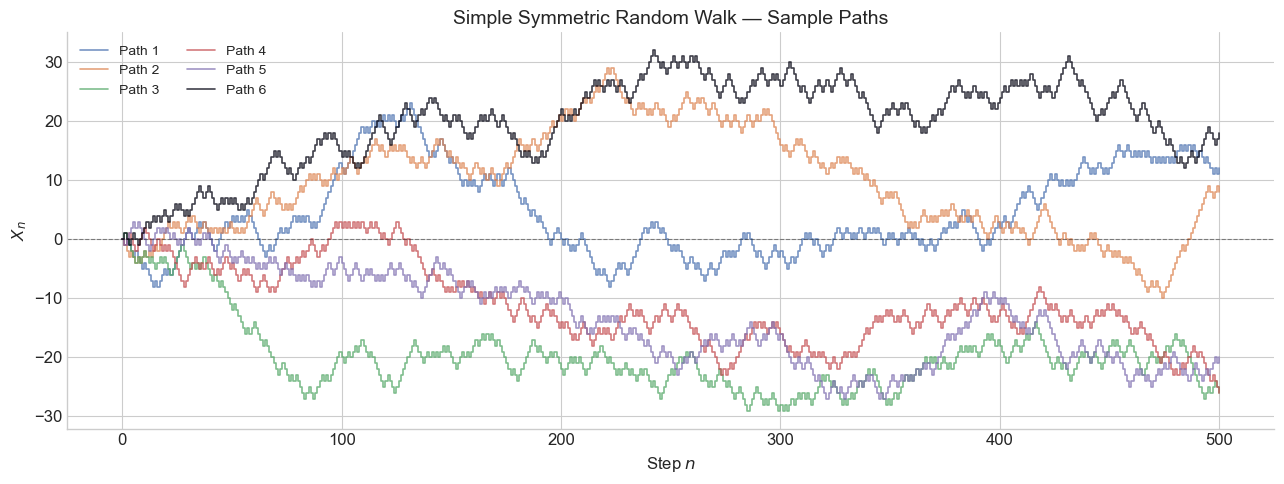

In [12]:
def simulate_random_walk(n_steps, n_paths=1, seed=None):
    if seed is not None:
        np.random.seed(seed)
    steps = np.random.choice([-1, 1], size=(n_paths, n_steps))
    paths = np.cumsum(steps, axis=1)
    return np.hstack([np.zeros((n_paths, 1)), paths])

n_steps = 500
n_paths = 6
paths = simulate_random_walk(n_steps, n_paths, seed=42)

fig, ax = plt.subplots(figsize=(13, 5))
t = np.arange(n_steps + 1)

for i, path in enumerate(paths):
    ax.step(t, path, where='post', alpha=0.75, linewidth=1.2, label=f'Path {i+1}')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('Step $n$')
ax.set_ylabel('$X_n$')
ax.set_title('Simple Symmetric Random Walk — Sample Paths', fontsize=14)
ax.legend(loc='upper left', fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

### **Part 2 -  Mean and Variance of Random Walk**
Let:
$$
X_n = \sum_{i=1}^{n} x_i,\qquad\mathbb{E}[x_0] = 0
$$
Then by linearity of expectation:
$$
\mathbb{E}[X_n] = \sum_{i=1}^n \mathbb{E}[x_i] = 0
$$

Since $x_i$(the increments) are independent with $\text{Var}(x_i) = 1$:
$$
\text{Var}(X_n) = \sum_{i=1}^n \text{Var}(x_i) = n
$$

**Interpretation**  
The variance grows linearly with time.  
This implies that the typical scale of fluctuations is:
$$
X_n = O(\sqrt{n})
$$

In [13]:
n_simulations = 10_000
checkpoints = [10, 50, 100, 250, 500]

all_paths = simulate_random_walk(max(checkpoints), n_simulations, seed=0)

print(f"{'n':>6}  {'E[X_n]  (theory = 0)':>24}  {'Var(X_n)  (theory = n)':>24}")
print("-" * 60)
for n in checkpoints:
    xn = all_paths[:, n]
    print(f"{n:>6}  {xn.mean():>24.4f}  {xn.var():>24.4f}")

     n      E[X_n]  (theory = 0)    Var(X_n)  (theory = n)
------------------------------------------------------------
    10                   -0.0300                   10.0519
    50                    0.0254                   50.5350
   100                   -0.0184                  101.5493
   250                   -0.0172                  250.6581
   500                   -0.0880                  502.6243


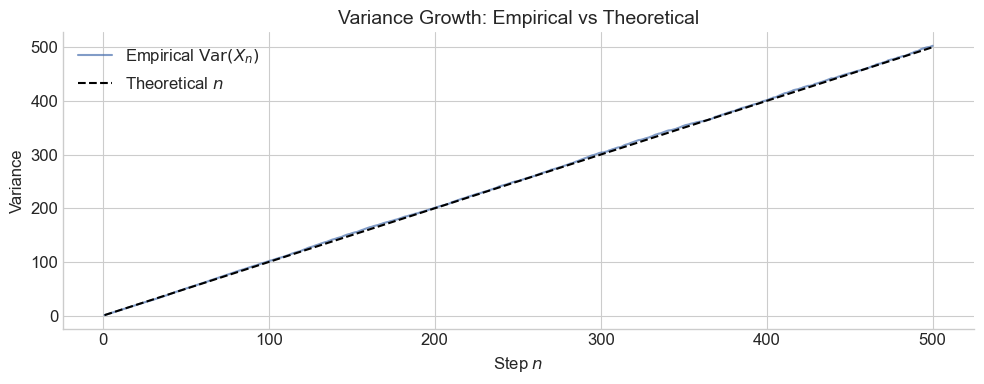

In [14]:
ns = np.arange(1, n_steps + 1)
empirical_var = all_paths[:, 1:n_steps+1].var(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ns, empirical_var, alpha=0.7, linewidth=1.5,
        label='Empirical $\\mathrm{Var}(X_n)$')
ax.plot(ns, ns, 'k--', linewidth=1.5, label='Theoretical $n$')
ax.set_xlabel('Step $n$')
ax.set_ylabel('Variance')
ax.set_title('Variance Growth: Empirical vs Theoretical', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### **Part 3 - Distribution of Random Walk**
#### **1. Exact formula**  
The position after $n$ steps depends on the number of $+1$ steps.

Let $R$ be the number of $+1$ steps. Then:

$$
R \sim \text{Binomial}(n, 1/2)
$$

The position is:

$$
X_n = 2R - n
$$

Therefore, for a given position $k$, we must have:

$$
R = \frac{n+k}{2}
$$

This leads to the probability mass function:

$$
P(X_n = k)
=
\binom{n}{\frac{n+k}{2}}
\cdot
\frac{1}{2^n}
$$

#### **2. Multiple Paths & Terminal Distribution**
With only a few paths it is hard to see the statistical structure. Simulating
100 paths together reveals two things at once:
- The **fan shape** - Based on Part 2, paths spread out over time, with spread $\sim \sqrt{n}$
- The **terminal distribution** — where paths end up at step $n$ follows a distribution that, by the CLT, converges to $\mathcal{N}(0, n)$

The histogram on the right shows the distribution of $X_n$ across all 100 paths
at the final step $n = 500$, overlaid with the theoretical $\mathcal{N}(0, n)$ density.

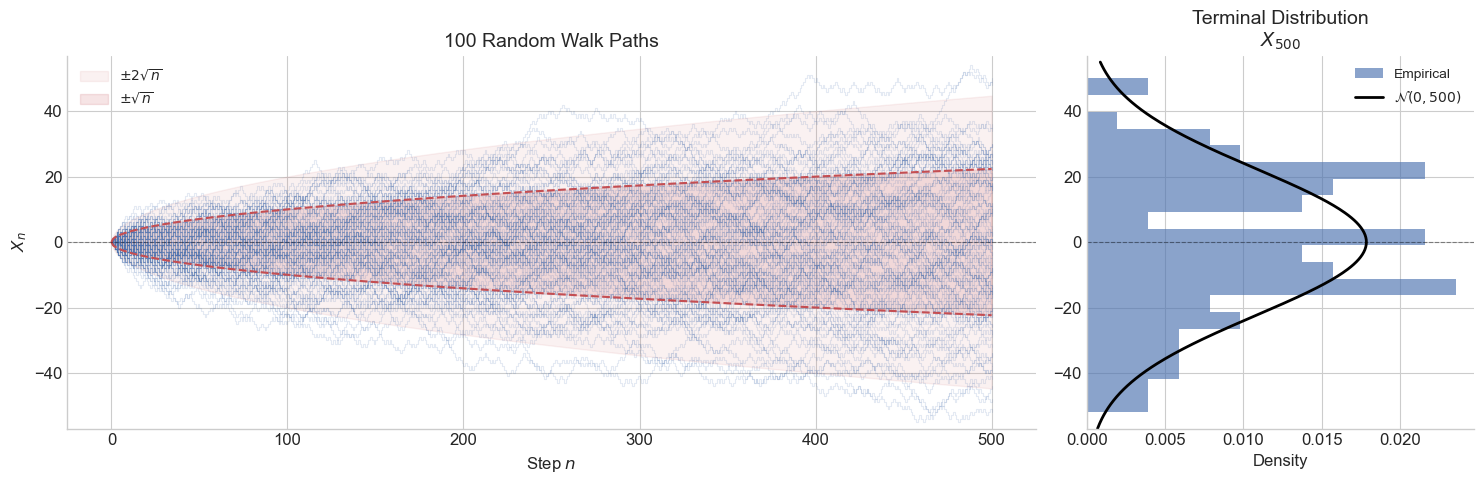

In [15]:
np.random.seed(42)
n_steps = 500
n_paths = 100
all_paths = simulate_random_walk(n_steps, n_paths, seed=42)
t = np.arange(n_steps + 1)
terminals = all_paths[:, -1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5),
                                gridspec_kw={'width_ratios': [2.5, 1]})

# Left: 100 paths
for path in all_paths:
    ax1.step(t, path, where='post', alpha=0.15, linewidth=0.8, color='#4C72B0')

# Overlay mean ± 1 and 2 std bands
ax1.fill_between(t, -2*np.sqrt(t),  2*np.sqrt(t),
                 alpha=0.08, color='#C44E52', label='$\\pm 2\\sqrt{n}$')
ax1.fill_between(t, -np.sqrt(t),  np.sqrt(t),
                 alpha=0.15, color='#C44E52', label='$\\pm \\sqrt{n}$')
ax1.plot(t, np.sqrt(t), color='#C44E52', linewidth=1.5, linestyle='--')
ax1.plot(t, -np.sqrt(t), color='#C44E52', linewidth=1.5, linestyle='--')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax1.set_xlabel('Step $n$')
ax1.set_ylabel('$X_n$')
ax1.set_title('100 Random Walk Paths', fontsize=14)
ax1.legend(fontsize=10)

# Right: terminal distribution
x_grid  = np.linspace(terminals.min() - 5, terminals.max() + 5, 300)
theory  = stats.norm.pdf(x_grid, loc=0, scale=np.sqrt(n_steps))

ax2.hist(terminals, bins=20, density=True, alpha=0.65,
         color='#4C72B0', orientation='horizontal', label='Empirical')
ax2.plot(theory, x_grid, 'k-', linewidth=2,
         label=f'$\\mathcal{{N}}(0,{n_steps})$')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax2.set_xlabel('Density')
ax2.set_title(f'Terminal Distribution\n$X_{{500}}$', fontsize=14)
ax2.legend(fontsize=10)

y_lim = max(abs(terminals.min()), abs(terminals.max())) + 5
ax1.set_ylim(-y_lim, y_lim)
ax2.set_ylim(-y_lim, y_lim)

plt.tight_layout()
plt.show()